
<div style="background-color: #1A3A5C; padding: 30px; border-radius: 10px; text-align: center;">
  <h1 style="color: white; font-size: 2em; margin-bottom: 8px;">
     Amostragem e Reconstrução de Sinais usando  sinais de áudio
  </h1>
  <h3 style="color: #AED6F1; font-weight: normal; margin-bottom: 4px;">
    Disciplina: Processamento Digital de Sinais
  </h3>
  <h3 style="color: #AED6F1; font-weight: normal;">
    Professora: Luciana Ribeiro Veloso — UFCG / DEE
  </h3>
</div>

---

> **Objetivo deste notebook:** apresentar, de forma integrada, a teoria da amostragem de sinais e um simulador interativo que permite visualizar em tempo real todos os estágios do processo — desde o sinal contínuo até a reconstrução pela interpolação sinc, passando pelo aliasing e o mapeamento de frequências.


## Sobre este notebook

Este notebook é uma extensão prática do laboratório de amostragem. Enquanto o simulador teórico trabalha com senóides sintéticas, aqui usamos sinais de áudio reais para tornar os efeitos da amostragem perceptíveis tanto visualmente (espectrogramas) quanto auditivamente (players de áudio).

São dois experimentos independentes:

| Experimento | Sinal de entrada | O que demonstra |
|---|---|---|
| **1 — Chirp**  | Varredura de frequência 0→22 kHz (30 s) | Efeito do aliasing no espectrograma de um sinal com todas as frequências |
| **2 — Microfone** | Sua voz gravada ao vivo (5 s) | Degradação perceptível da qualidade com fatores de decimação crescentes |

### Conceito central: decimação como modelo de subamostagem

Em ambos os experimentos, a redução da taxa de amostragem é feita por decimação — selecionar 1 amostra a cada $M$ — sem filtro anti-aliasing:

$$x_{r}(n) = x(n \cdot M), \qquad F_d = \frac{F_s}{M}$$

Isso é deliberadamente errado do ponto de vista prático, pois omite o filtro anti-aliasing — justamente para que o aliasing fique visível e audível.

---

> **Pré-requisitos:** Teorema de Nyquist, aliasing, espectrograma, interpolação sinc.
> Consulte o notebook *Simulador de Amostragem e Reconstrução* para a fundamentação teórica completa.


---

## Experimento 1 — Sinal Chirp e Aliasing Espectral

### O que é um sinal chirp?

Um **chirp linear** (também chamado de *sweep* ou varredura de frequência) é um sinal senoidal cuja frequência aumenta linearmente com o tempo:

$$x_c(t) = \sin\!\left(2\pi\left(f_0 + \frac{f_1 - f_0}{2\,T}\,t\right)t\right), \qquad 0 \leq t \leq T$$

Neste experimento: $f_0 = 0$ Hz, $f_1 = 22\,050$ Hz, $T = 30$ s — ou seja, o sinal percorre todo o espectro audível de forma contínua.

>Por que usar um chirp?</strong><br>
Como o chirp contém todas as frequências em instantes diferentes, o espectrograma revela visualmente <em>exatamente em qual frequência o aliasing começa</em>, aparece como uma linha que "dobra" ao atingir $F_s/2$ em vez de continuar subindo.

### O espectrograma

O espectrograma é uma representação tempo-frequência obtida pela STFT (*Short-Time Fourier Transform*):

$$S(t, f) = \left|\int_{-\infty}^{+\infty} x(\tau)\,w(\tau - t)\,e^{-j2\pi f \tau}\,d\tau\right|^2$$

onde $w(t)$ é uma janela deslizante (ex.: Hann). O resultado é uma imagem onde:
- **Eixo horizontal** → tempo
- **Eixo vertical** → frequência
- **Cor/intensidade** → energia em dB: $10\log_{10}S(t,f)$

### O que esperar neste experimento

Com $F_s = 44\,100$ Hz decimado por fator $M = 10$ → $F_d = 4\,410$ Hz:

$$F_{NyquistNova} = \frac{4410}{2} = 2205 \text{ Hz}$$

Portanto, toda componente do chirp acima de 2.205 Hz causará aliasing. No espectrograma, a linha diagonal do chirp deve:
1. Subir linearmente de 0 até 2.205 Hz
2. "Dobrar", refletir de volta para baixo ao atingir $F_{Nyquist}$
3. Repetir o padrão em dente de serra (gráfico de dobramento)

>Frequência percebida pelo dobramento:</strong><br><br>
>$$F_{alias} = \left|\,F - \text{round}\!\left(\frac{F}{F_s}\right)\cdot F_s\,\right|$$

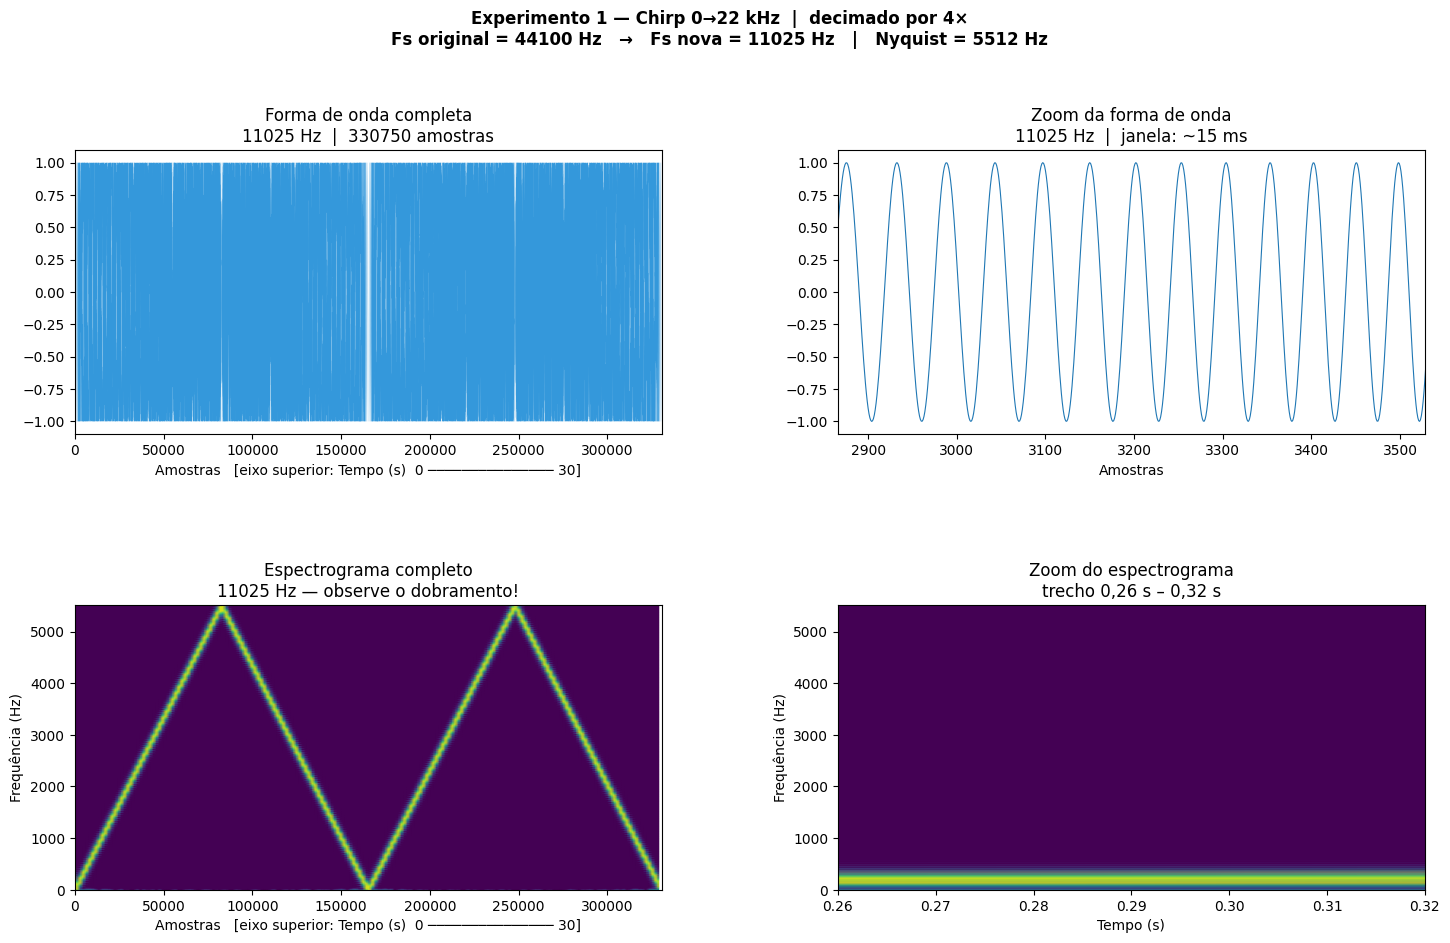

Taxa de amostragem : 11025 Hz
Nyquist            : 5512 Hz
Aliasing acima de  : 5512 Hz


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import chirp, spectrogram
from IPython.display import Audio, display

# --- 1. CONFIGURAÇÕES TÉCNICAS ---
fs_original     = 44100
duracao         = 30.0
n_amostras_orig = 1323000
fator           = 4
fs_nova         = int(fs_original / fator)   # 4410 Hz

# Gerar Dados
t_orig     = np.linspace(0, duracao, n_amostras_orig, endpoint=False)
sinal_orig = chirp(t_orig, f0=0, f1=22050, t1=duracao, method='linear')
sinal_res  = sinal_orig[::fator]
n_amostras_res = len(sinal_res)

# Calcular Espectrograma
freqs, tempos, Sxx = spectrogram(sinal_res, fs_nova, nperseg=2048)

# --- 2. PLOTAGEM ---
# subplots_adjust: top=0.82 reserva 18% para o suptitle de 2 linhas
# hspace=0.6 separa as duas linhas de subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
plt.subplots_adjust(top=0.82, bottom=0.08,
                    left=0.07, right=0.97,
                    hspace=0.60, wspace=0.30)

ax1, ax2 = axes[0]
ax3, ax4 = axes[1]

# [0,0] WAVEFORM COMPLETA
# Eixo secundário de tempo embutido no xlabel (evita twiny que sobe até o suptitle)
ax1.plot(sinal_res, lw=0.05, color='#3498db')
ax1.set_title(f"Forma de onda completa\n{fs_nova} Hz  |  {n_amostras_res} amostras")
ax1.set_xlabel("Amostras   [eixo superior: Tempo (s)  0 ─────────────── 30]")
ax1.set_xlim([0, n_amostras_res])

# [0,1] ZOOM WAVEFORM
ax2.plot(sinal_res, lw=0.8)
ax2.set_xlim([2866, 3528])
ax2.set_title(f"Zoom da forma de onda\n{fs_nova} Hz  |  janela: ~15 ms")
ax2.set_xlabel("Amostras")

# [1,0] ESPECTROGRAMA COMPLETO
ax3.pcolormesh(tempos * fs_nova, freqs,
               10 * np.log10(Sxx + 1e-10), shading='gouraud', cmap='viridis')
ax3.set_title(f"Espectrograma completo\n{fs_nova} Hz — observe o dobramento!")
ax3.set_ylabel("Frequência (Hz)")
ax3.set_xlabel("Amostras   [eixo superior: Tempo (s)  0 ─────────────── 30]")
ax3.set_xlim([0, n_amostras_res])

# [1,1] ZOOM ESPECTROGRAMA
ax4.pcolormesh(tempos, freqs,
               10 * np.log10(Sxx + 1e-10), shading='gouraud', cmap='viridis')
ax4.set_xlim([0.26, 0.32])
ax4.set_title(f"Zoom do espectrograma\ntrecho 0,26 s – 0,32 s")
ax4.set_xlabel("Tempo (s)")
ax4.set_ylabel("Frequência (Hz)")

# suptitle posicionado em y=0.96 dentro do espaço reservado acima de top=0.82
fig.suptitle(
    f"Experimento 1 — Chirp 0→22 kHz  |  decimado por {fator}×\n"
    f"Fs original = {fs_original} Hz   →   Fs nova = {fs_nova} Hz"
    f"   |   Nyquist = {fs_nova//2} Hz",
    fontsize=12, fontweight='bold', y=0.96
)
plt.show()

# --- 3. REPRODUÇÃO ---
print(f"Taxa de amostragem : {fs_nova} Hz")
print(f"Nyquist            : {fs_nova//2} Hz")
print(f"Aliasing acima de  : {fs_nova//2} Hz")
display(Audio(data=sinal_res, rate=fs_nova))

### 💡 O que observar nos gráficos acima

>Espectrograma completo (gráfico inferior esquerdo)</strong><br>
>A linha diagonal do chirp sobe linearmente até ~2.205 Hz (= Nyquist) e então <strong>dobra de volta</strong>, criando um padrão em "V" repetido. Esse é o dobramento espectral previsto pelo gráfico de dobramento.

>No player de áudio</strong><br>
>Ouça como o tom sobe até certo ponto e depois <strong>parece descer</strong> — isso é o aliasing tornando-se audível. O ouvido percebe a frequência alias, não a frequência real do chirp.

#### Questões
1. No espectrograma, identifique o instante (em segundos) em que o dobramento ocorre pela primeira vez. Calcule a frequência do chirp nesse instante e confirme que é igual a $F_{Nyquist} = F_s/2$.
2. Quantas "dobras" são visíveis no espectrograma ao longo dos 30 segundos? Explique por que esse número depende de $F_s^{orig}/F_s^{nova}$.
3. O que mudaria se aplicássemos um **filtro anti-aliasing** (Butterworth passa-baixa em $F_s^{nova}/2$) antes da decimação?

---


---

## Experimento 2 — Efeito da Taxa de Amostragem na Voz Gravada

### Motivação

O Experimento 1 mostrou o aliasing em um sinal sintético. Agora você vai gravar sua própria voz e ouvi-la degradada em diferentes taxas de amostragem, tornando o efeito do aliasing imediatamente perceptível.

### Fatores de decimação utilizados

| Fator $M$ | $F_s^{nova} = 44100/M$ | $F_{Nyquist}^{nova}$ | Faixa preservada | Qualidade esperada |
|:---------:|:---------------------:|:-------------------:|:----------------:|:-----------------:|
| 1 | 44.100 Hz | 22.050 Hz | 0 – 22 kHz | **Referência (CD)** |
| 4 | 11.025 Hz | 5.512 Hz | 0 – 5,5 kHz | Boa (voz inteligível) |
| 8 | 5.512 Hz | 2.756 Hz | 0 – 2,7 kHz | Degradada (voz de telefone antigo) |
| 50 | 882 Hz | 441 Hz | 0 – 441 Hz | **Completamente distorcida** |

### Efeito perceptivo esperado

>**Fator 1 (44.100 Hz):** qualidade de CD — reprodução fiel da voz original.
>**Fator 4 (11.025 Hz):** voz reconhecível com leve perda de brilho nas consoantes (fricativas como "s", "f" acima de 5 kHz são cortadas).
>**Fator 8 (5.512 Hz):** semelhante a uma ligação telefônica de baixa qualidade — vogais inteligíveis, consoantes comprometidas.
>**Fator 50 (882 Hz):** apenas as componentes mais graves da voz (<441 Hz) são preservadas. O restante é aliasing — o sinal soará como ruído ou distorção grave.

### Por que a decimação sem filtro é tão destrutiva?

Ao decimarmos por $M$ sem filtrar primeiro, todas as componentes de frequência $F > F_s^{nova}/2$ são dobradas para dentro da banda $[0, F_s^{nova}/2]$, onde se somam ao sinal legítimo:

$$x_{alias}(t) = \underbrace{x_c(t)}_{\text{componentes abaixo de } F_s^{nova}/2} + \underbrace{\sum_{k\neq 0} x_c\!\left(t - \frac{k}{F_s^{nova}}\right)}_{\text{aliasing das réplicas}}$$

A solução correta é aplicar um filtro passa-baixa com $f_c = F_s^{nova}/2$ antes de decimar.

### O espectrograma como ferramenta diagnóstica

Para cada fator, o espectrograma mostrará:
- **Fator 1:** energia concentrada nas frequências da fala (tipicamente 100–4.000 Hz) com harmônicos visíveis
- **Fatores 4 e 8:** espectro truncado em $F_{NyquistNova}$ — componentes acima somem ou dobram
- **Fator 50:** o espectrograma estará repleto de energia "falsa" (aliasing) em toda a banda

>⚠️ Atenção ao executar:</strong> ao clicar no botão, o microfone abrirá por 5 segundos. Fale claramente (uma frase completa). Aguarde o processamento — os 4 gráficos e players serão gerados automaticamente em sequência.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import spectrogram
import sounddevice as sd
import soundfile as sf
import IPython.display as ipd
import ipywidgets as widgets
from io import BytesIO

# --- Configurações Iniciais ---
FS_ORIGINAL = 44100
DURACAO     = 5
FATORES     = [1, 4, 8, 50]   # Fatores de decimação para simular

def processar_e_plotar(audio_orig, fs_orig):
    """
    Para cada fator de decimação em FATORES:
      1. Decima o sinal (sem filtro anti-aliasing — para mostrar o aliasing)
      2. Plota a forma de onda e o espectrograma lado a lado
      3. Reproduz o áudio via player IPython
    """
    for fator in FATORES:
        fs_nova   = int(fs_orig / fator)
        sinal_res = audio_orig[::fator]

        fig = plt.figure(figsize=(15, 4))
        gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.3)

        # Forma de onda
        ax1 = fig.add_subplot(gs[0, 0])
        ax1.plot(sinal_res, lw=0.3, color='#2980b9')
        ax1.set_title(
            f"Fator {fator}×  |  Fs = {fs_nova} Hz  |  "
            f"Nyquist = {fs_nova//2} Hz\nForma de onda"
        )
        ax1.set_xlabel("Amostras")
        ax1.set_ylabel("Amplitude")

        # Espectrograma
        ax2 = fig.add_subplot(gs[0, 1])
        f_sg, ts_sg, Sxx = spectrogram(sinal_res, fs_nova, nperseg=1024)
        pcm = ax2.pcolormesh(ts_sg, f_sg,
                             10 * np.log10(Sxx + 1e-10),
                             shading='gouraud', cmap='viridis')
        plt.colorbar(pcm, ax=ax2, label='dB')
        ax2.set_title(
            f"Espectrograma  |  Fator {fator}×  |  "
            f"Nyquist = {fs_nova//2} Hz"
        )
        ax2.set_xlabel("Tempo (s)")
        ax2.set_ylabel("Frequência (Hz)")

        plt.show()

        # Player de áudio
        print(f"  Fator {fator}×  —  Fs = {fs_nova} Hz  "
              f"|  Nyquist = {fs_nova//2} Hz  "
              f"|  {len(sinal_res)} amostras")
        display(ipd.Audio(sinal_res, rate=fs_nova))
        print("-" * 80)

def ao_clicar_no_botao(b):
    """Callback do botão: grava o microfone e chama o processamento."""
    with saida:
        saida.clear_output()
        print(f" GRAVANDO... fale por {DURACAO} segundos!")
        gravacao = sd.rec(int(DURACAO * FS_ORIGINAL),
                          samplerate=FS_ORIGINAL, channels=1)
        sd.wait()
        print(" Gravação concluída! Processando aliasing para os 4 fatores...")
        print("=" * 80)
        audio_final = gravacao.flatten()
        processar_e_plotar(audio_final, FS_ORIGINAL)

# --- Interface Gráfica ---
botao = widgets.Button(
    description='Iniciar Gravação',
    button_style='danger',
    tooltip=f'Clique para gravar {DURACAO} segundos de áudio pelo microfone',
    layout=widgets.Layout(width='220px', height='40px')
)

saida = widgets.Output()
botao.on_click(ao_clicar_no_botao)

print("Clique no botão abaixo para iniciar o experimento: (sugestão de frase: As folhas frescas caem suavemente sobre o chão seco e frio. )")
display(botao, saida)


Clique no botão abaixo para iniciar o experimento: (sugestão de frase: As folhas frescas caem suavemente sobre o chão seco e frio. )


Button(button_style='danger', description='Iniciar Gravação', layout=Layout(height='40px', width='220px'), sty…

Output()

---

## Análise dos Resultados e Questões

### O que comparar entre os 4 fatores

Após executar o Experimento 2, analise os espectrogramas e players lado a lado:

| Aspecto | Fator 1 | Fator 4 | Fator 8 | Fator 50 |
|---|:---:|:---:|:---:|:---:|
| Voz inteligível? | ✅ | ✅ | ⚠️ | ❌ |
| Harmônicos da voz visíveis? | ✅ | ✅ | Parcial | ❌ |
| Aliasing visível no espectrograma? | ❌ | Leve | ✅ | ✅✅ |
| Qualidade subjetiva | Excelente | Boa | Aceitável | Irreconhecível |

---

### Questões para o relatório

**Sobre o Experimento 1 (Chirp):**

1. No espectrograma do chirp decimado, identifique a frequência de Nyquist visualmente. Ela coincide com $F_s^{nova}/2 = 2205$ Hz?

2. Calcule $F_{alias}$ para um chirp de $F = 10000$ Hz com $F_s^{nova} = 4410$ Hz usando a fórmula de dobramento. Verifique no espectrograma.

3. O que aconteceria com o espectrograma se usássemos um filtro Butterworth de ordem 8 com $f_c = 2205$ Hz antes de decimar?

**Sobre o Experimento 2 (Voz):**

4. Para o fator 8 ($F_s = 5512$ Hz): quais fonemas da sua fala foram mais afetados pela perda de frequências acima de 2756 Hz? (Pense em consoantes fricativas: /s/, /f/, /ch/)

5. Para o fator 50 ($F_s = 882$ Hz): a energia espectral acima de 441 Hz no espectrograma é sinal real ou aliasing? Como você distingue?

6. Compare os espectrogramas dos fatores 1 e 8. Os **harmônicos da frequência fundamental da voz** (F0 ≈ 100–200 Hz) ainda são visíveis no fator 8? E no fator 50?

**Questão integradora:**

7. O padrão telefônico clássico usa $F_s = 8000$ Hz. Com base nos resultados deste experimento, justifique por que essa taxa foi escolhida para transmissão de voz inteligível. Qual seria o efeito de usar $F_s = 5512$ Hz (fator 8)?

---

## Referências

- **Oppenheim, A.V.; Schafer, R.W.** *Processamento em Tempo Discreto de Sinais*, 3ª ed. Pearson, 2013. *(Cap. 4)*
- **Oppenheim, A.V.; Willsky, A.S.** *Sinais e Sistemas*, 2ª ed. Pearson, 2010. *(Cap. 7)*
- **Proakis, J.G.; Manolakis, D.G.** *Digital Signal Processing*, 4ª ed. Pearson, 2007.
- **SciPy Documentation:** `scipy.signal.chirp`, `scipy.signal.spectrogram`

---

<div style="text-align: center; color: #888; font-size: 0.85em; margin-top: 20px;">
Laboratório de PDS — UFCG / DEE &nbsp;|&nbsp; Profa. Luciana Ribeiro Veloso
</div>
